## Анализ тональности комментариев

In [3]:
import pandas as pd
import numpy as np
import re
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import nltk
from nltk.corpus import stopwords

# Загрузка стоп-слов
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ROG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv(
    'com.csv', 
    sep=','
)

In [8]:
df.head(10)

,tonality,comment
0,1,скотина! что сказать
1,0,я сегодня проезжала по рабочей и между домами ...
2,0,очередной лохотрон. зачем придумывать очередно...
3,0,"ретро дежавю ... сложно понять чужое сердце , ..."
4,0,а когда мы статус агрогородка получили?
5,0,2 августа поздно вечером нашли вот такую потер...
6,0,вчера надыбала новые стикеры #u2a94ec7fabs#
7,1,",2 заколоть этого плешивого урода что бы крякн..."
8,0,а еще на стоянке никто не проверяет безопаснос...
9,0,"красота..!! если есть, что показать??!! почему..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   tonality  248290 non-null  object
 1   comment   248290 non-null  object
dtypes: object(2)
memory usage: 3.8+ MB


## Чистка и токенизация текста

In [10]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def preprocess_with_tokenization(text):
    # Базовая очистка
    text = text.replace("ё", "е")
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', 'URL', text)
    text = re.sub('[^a-zA-Zа-яА-Я]+', ' ', text)
    text = re.sub(' +', ' ', text)
    text = text.lower()
    
    # Токенизация через NLTK
    tokens = word_tokenize(text)
    
    # Удаление стоп-слов и коротких токенов
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    return tokens  # Возвращаем список токенов

df['tokens'] = df['comment'].apply(preprocess_with_tokenization)

In [11]:
df.head()

,tonality,comment,tokens
0,1,скотина! что сказать,"[скотина, сказать]"
1,0,я сегодня проезжала по рабочей и между домами ...,"[сегодня, проезжала, рабочей, домами, снитенко..."
2,0,очередной лохотрон. зачем придумывать очередно...,"[очередной, лохотрон, придумывать, очередной, ..."
3,0,"ретро дежавю ... сложно понять чужое сердце , ...","[ретро, дежавю, сложно, понять, чужое, сердце,..."
4,0,а когда мы статус агрогородка получили?,"[статус, агрогородка, получили]"


In [12]:
df['text_for_vectorizer'] = df['tokens'].apply(' '.join)

In [13]:
df.head()

,tonality,comment,tokens,text_for_vectorizer
0,1,скотина! что сказать,"[скотина, сказать]",скотина сказать
1,0,я сегодня проезжала по рабочей и между домами ...,"[сегодня, проезжала, рабочей, домами, снитенко...",сегодня проезжала рабочей домами снитенко гомо...
2,0,очередной лохотрон. зачем придумывать очередно...,"[очередной, лохотрон, придумывать, очередной, ...",очередной лохотрон придумывать очередной налог...
3,0,"ретро дежавю ... сложно понять чужое сердце , ...","[ретро, дежавю, сложно, понять, чужое, сердце,...",ретро дежавю сложно понять чужое сердце лиш ощ...
4,0,а когда мы статус агрогородка получили?,"[статус, агрогородка, получили]",статус агрогородка получили


In [14]:
ton_values = df['tonality'].drop_duplicates()
print(f"Уникальные классы: {', '.join(map(str, ton_values))}")
print(f"Всего классов: {ton_values.count()}")

Уникальные классы: 1, 0, OBSCEN, 2
Всего классов: 4


In [15]:
dist = df['tonality'].value_counts()
print("\nРаспределение:")
for val, cnt in dist.items():
    pct = cnt/len(df)*100
    print(f"  {val}: {cnt:4d} ({pct:5.2f}%) {'█' * int(pct)}")


Распределение:
  0: 203685 (82.04%) ██████████████████████████████████████████████████████████████████████████████████
  1: 36826 (14.83%) ██████████████
  2: 5460 ( 2.20%) ██
  OBSCEN: 2319 ( 0.93%) 


In [16]:
print("\nПримеры комментариев:")
for name, group in df.groupby('tonality'):
    print(f"\n[{name}]")
    for idx, comment in enumerate(group['comment'].head(3), 1):
        preview = comment[:80] + ('...' if len(comment) > 80 else '')
        print(f"  {idx}. {preview}")


Примеры комментариев:

[0]
  1. я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином (...
  2. очередной лохотрон. зачем придумывать очередной налог на воздух, если можно обья...
  3. ретро дежавю ... сложно понять чужое сердце , лиш ощутить музыкой видимо

[1]
  1. скотина! что сказать
  2. ,2 заколоть этого плешивого урода что бы крякнул как селезень гандон штопанный в...
  3. долбоебы это фэйк

[2]
  1. надо было его собаку на заборе повесить ,жалко скотинку конечно но это было бы п...
  2. давайте его ;растреляем; в театре на спектакле гнилыми помидорами и все!!
  3. вот растрелять бы этих богослужителей, грабить доверчивых , и одеваются в золото...

[OBSCEN]
  1. ITY эти генеральши знают где соснуть и раздвинуть зад и передок ,позор страны
  2. ITY полизал бы и всунул
  3. ITY моя любит попа игрушкой секс с в попку мою класс


In [17]:
df.head()

,tonality,comment,tokens,text_for_vectorizer
0,1,скотина! что сказать,"[скотина, сказать]",скотина сказать
1,0,я сегодня проезжала по рабочей и между домами ...,"[сегодня, проезжала, рабочей, домами, снитенко...",сегодня проезжала рабочей домами снитенко гомо...
2,0,очередной лохотрон. зачем придумывать очередно...,"[очередной, лохотрон, придумывать, очередной, ...",очередной лохотрон придумывать очередной налог...
3,0,"ретро дежавю ... сложно понять чужое сердце , ...","[ретро, дежавю, сложно, понять, чужое, сердце,...",ретро дежавю сложно понять чужое сердце лиш ощ...
4,0,а когда мы статус агрогородка получили?,"[статус, агрогородка, получили]",статус агрогородка получили


In [18]:
print(df["tonality"].unique())

['1' '0' 'OBSCEN' '2']


In [19]:
# Сначала преобразуем всё в строки для единообразия
df['tonality'] = df['tonality'].astype(str)

# Теперь маппинг со строковыми ключами
obscene_mapping = {
    'OBSCEN': '3',
    '0': '0',
    '1': '1', 
    '2': '2'
}

df['tonality'] = df['tonality'].map(obscene_mapping)

# Преобразуем обратно в числа
df['tonality'] = pd.to_numeric(df['tonality'])

# Проверка
print(df['tonality'].unique())
print(df['tonality'].value_counts().sort_index())

[1 0 3 2]
tonality
0    203685
1     36826
2      5460
3      2319
Name: count, dtype: int64


In [20]:
df.head()

,tonality,comment,tokens,text_for_vectorizer
0,1,скотина! что сказать,"[скотина, сказать]",скотина сказать
1,0,я сегодня проезжала по рабочей и между домами ...,"[сегодня, проезжала, рабочей, домами, снитенко...",сегодня проезжала рабочей домами снитенко гомо...
2,0,очередной лохотрон. зачем придумывать очередно...,"[очередной, лохотрон, придумывать, очередной, ...",очередной лохотрон придумывать очередной налог...
3,0,"ретро дежавю ... сложно понять чужое сердце , ...","[ретро, дежавю, сложно, понять, чужое, сердце,...",ретро дежавю сложно понять чужое сердце лиш ощ...
4,0,а когда мы статус агрогородка получили?,"[статус, агрогородка, получили]",статус агрогородка получили


In [21]:
# Используем очищенные тексты
texts = df['text_for_vectorizer'].values
labels = df['tonality'].values

In [22]:
print(f"Всего текстов: {len(texts)}")
print(f"Распределение классов:")
for label in sorted(np.unique(labels)):
    count = sum(labels == label)
    print(f"  Класс {label}: {count} ({count/len(labels)*100:.2f}%)")

Всего текстов: 248290
Распределение классов:
  Класс 0: 203685 (82.04%)
  Класс 1: 36826 (14.83%)
  Класс 2: 5460 (2.20%)
  Класс 3: 2319 (0.93%)


In [23]:
# РАЗДЕЛЕНИЕ НА ТРЕНИРОВОЧНУЮ И ТЕСТОВУЮ ВЫБОРКИ
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels  # сохраняем пропорции классов
)

In [24]:
print(f"\nРазмер тренировочной выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")


Размер тренировочной выборки: 198632
Размер тестовой выборки: 49658


In [25]:
# ТОКЕНИЗАЦИЯ И ПОДГОТОВКА ПОСЛЕДОВАТЕЛЬНОСТЕЙ
max_words = 10000  # максимальное количество слов в словаре
max_len = 100      # максимальная длина последовательности

In [26]:
# Создание токенизатора
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [27]:
# Преобразование текстов в последовательности
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [28]:
# Паддинг последовательностей до одинаковой длины
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [29]:
print(f"\nРазмер словаря: {len(tokenizer.word_index)}")
print(f"Форма тренировочных данных: {X_train_pad.shape}")
print(f"Форма тестовых данных: {X_test_pad.shape}")


Размер словаря: 210406
Форма тренировочных данных: (198632, 100)
Форма тестовых данных: (49658, 100)


In [30]:
# СОЗДАНИЕ МОДЕЛИ LSTM
def create_lstm_model(vocab_size, max_length, num_classes):
    model = Sequential([
        # Embedding слой
        Embedding(vocab_size, 128, input_length=max_length),
        
        # Первый Bidirectional LSTM слой
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
        
        # Второй LSTM слой
        LSTM(32, dropout=0.3, recurrent_dropout=0.3),
        
        # Полносвязные слои
        Dense(64, activation='relu'),
        Dropout(0.5),
        
        # Выходной слой
        Dense(num_classes, activation='softmax')
    ])
    
    return model

In [31]:
# Определяем количество классов
num_classes = len(np.unique(labels))
print(f"\nКоличество классов: {num_classes}")


Количество классов: 4


In [32]:
# Создание модели
model = create_lstm_model(max_words, max_len, num_classes)

In [33]:
# Компиляция модели
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [34]:
# Вывод архитектуры модели
print("\nАрхитектура модели:")
model.summary()



Архитектура модели:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 128)          1280000   
                                                                 
 bidirectional (Bidirection  (None, 100, 128)          98816     
 al)                                                             
                                                                 
 lstm_1 (LSTM)               (None, 32)                20608     
                                                                 
 dense (Dense)               (None, 64)                2112      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 4)                 260       
                                   

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# КОЛЛБЭКИ ДЛЯ ОБУЧЕНИЯ
callbacks = [
    # Ранняя остановка при отсутствии улучшений
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Сохранение лучшей модели
    ModelCheckpoint(
        'best_lstm_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    
    # Уменьшение learning rate при плато
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1
    )
]

In [42]:
from sklearn.utils import class_weight

# Вычисляем веса для классов
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Веса классов:", class_weight_dict)

Веса классов: {0: 0.30474752681837153, 1: 1.685550388649401, 2: 11.368589743589743, 3: 26.769811320754716}


In [43]:
# ОБУЧЕНИЕ МОДЕЛИ
print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛИ")
print("="*60)

history = model.fit(
    X_train_pad, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


ОБУЧЕНИЕ МОДЕЛИ
Epoch 1/20
1242/1242 [==============================] - ETA: 0s - loss: 0.9483 - accuracy: 0.6451
Epoch 1: val_accuracy did not improve from 0.82100
1242/1242 [==============================] - 1067s 855ms/step - loss: 0.9483 - accuracy: 0.6451 - val_loss: 0.8192 - val_accuracy: 0.6502 - lr: 2.5000e-04
Epoch 2/20
1242/1242 [==============================] - ETA: 0s - loss: 0.6197 - accuracy: 0.7599
Epoch 2: val_accuracy improved from 0.82100 to 0.86229, saving model to best_lstm_model.keras
1242/1242 [==============================] - 1100s 885ms/step - loss: 0.6197 - accuracy: 0.7599 - val_loss: 0.5293 - val_accuracy: 0.8623 - lr: 2.5000e-04
Epoch 3/20
1242/1242 [==============================] - ETA: 0s - loss: 0.5512 - accuracy: 0.7838
Epoch 3: val_accuracy improved from 0.86229 to 0.87777, saving model to best_lstm_model.keras
1242/1242 [==============================] - 1099s 885ms/step - loss: 0.5512 - accuracy: 0.7838 - val_loss: 0.4553 - val_accuracy: 0.8778 - 

In [44]:
# ОЦЕНКА МОДЕЛИ
print("\n" + "="*60)
print("ОЦЕНКА МОДЕЛИ")
print("="*60)

# Оценка на тестовых данных
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


ОЦЕНКА МОДЕЛИ
Test Loss: 0.3634
Test Accuracy: 0.9013


In [45]:
# Предсказания
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

1552/1552 [==============================] - 32s 20ms/step


In [46]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9508    0.9431    0.9470     40737
           1     0.6983    0.6945    0.6964      7365
           2     0.5939    0.6923    0.6393      1092
           3     0.7095    1.0000    0.8301       464

    accuracy                         0.9013     49658
   macro avg     0.7381    0.8325    0.7782     49658
weighted avg     0.9033    0.9013    0.9019     49658



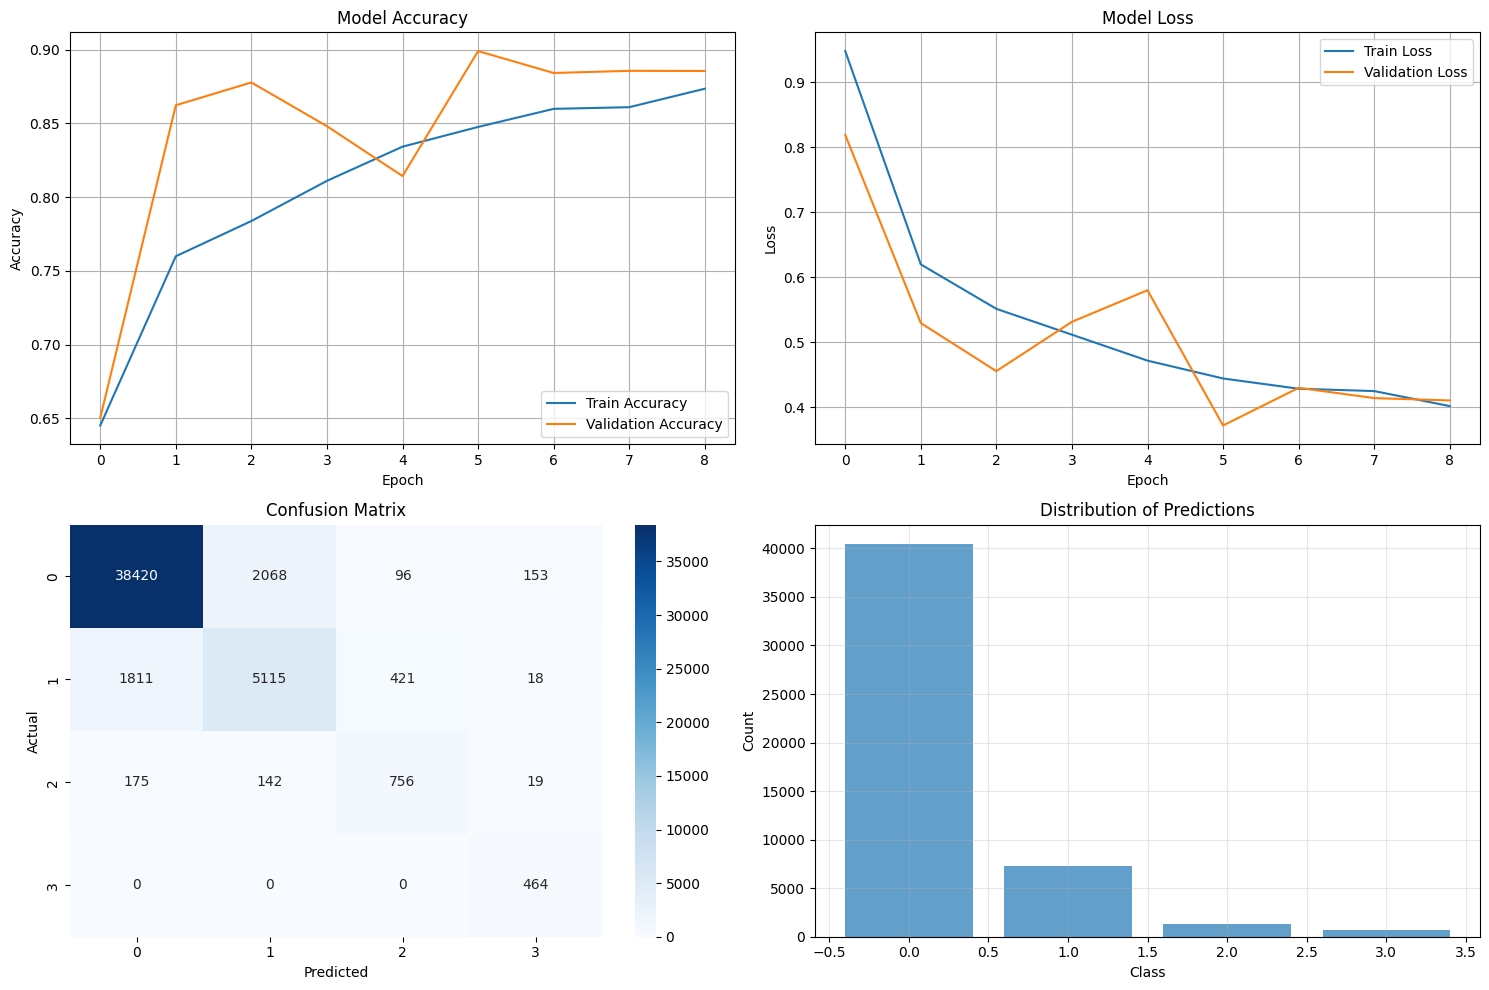

In [47]:
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График точности
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# График потерь
axes[0, 1].plot(history.history['loss'], label='Train Loss')
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1, 0], cmap='Blues')
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# Распределение предсказаний
unique, counts = np.unique(y_pred_classes, return_counts=True)
axes[1, 1].bar(unique, counts, alpha=0.7)
axes[1, 1].set_title('Distribution of Predictions')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()